### Predicting endotypes (A and B) in trauma

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import classification_report

In [2]:
# import the proteomics data 

clin = pd.read_csv('clin_ready.csv', header = 0, index_col=0)
clin = clin.drop(labels = [1578], axis = 0)
prot = pd.read_csv('raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('prot_filtered.csv', header = 0, index_col=0)
prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
print(prot.shape)

# import indices
# ENDOTYPE A = 0
# ENDOTYPE B = 1

indices = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/exported_indices.csv', index_col = 0)

(414, 4979)


In [5]:
# scale df and filter
scaler = StandardScaler()
scaled = scaler.fit_transform(prot)
scaled = pd.DataFrame(scaled, index=prot.index, columns=prot.columns)

In [6]:
cols = ['ASB9.19601.15', 'PROC.3758.68','CPLX2.15321.8', 'CLIC5.12475.48', 'ADSSL1.13998.26','HIST2H2BE.14143.8']
data = scaled.filter(items = cols)
X_train, X_test, y_train, y_test = train_test_split(data, indices.iloc[:,0].ravel(), random_state=121)

# modelling
clf = LogisticRegression(random_state=123).fit(X_train, y_train)
preds = clf.predict(X_test)

print(classification_report(y_test, preds, target_names=["A", "B"]))

              precision    recall  f1-score   support

           A       0.88      0.98      0.93        61
           B       0.97      0.81      0.89        43

    accuracy                           0.91       104
   macro avg       0.93      0.90      0.91       104
weighted avg       0.92      0.91      0.91       104



In [7]:
### repeat the same experiment with CV 
y = indices.iloc[:,0].ravel()
clf = LogisticRegressionCV(cv=5, random_state=124).fit(X_train, y_train)
preds2 = clf.predict(X_test)
print(classification_report(y_test, preds2, target_names=["A", "B"]))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00        61
           B       1.00      1.00      1.00        43

    accuracy                           1.00       104
   macro avg       1.00      1.00      1.00       104
weighted avg       1.00      1.00      1.00       104



In [9]:
from sklearn.model_selection import cross_validate
clf = LogisticRegression(random_state=123)
scores = cross_validate(clf, data, y, cv=5, scoring = ['roc_auc', 'balanced_accuracy', 'precision', 'recall'])
scores

{'fit_time': array([0.00251508, 0.00204682, 0.00151825, 0.00149584, 0.00183201]),
 'score_time': array([0.00324106, 0.00154185, 0.00142574, 0.00142598, 0.001472  ]),
 'test_roc_auc': array([0.97272727, 0.98275862, 0.98020434, 0.99425287, 0.96164021]),
 'test_balanced_accuracy': array([0.86590909, 0.90453384, 0.90453384, 0.89655172, 0.87433862]),
 'test_precision': array([0.95454545, 0.96      , 0.96      , 1.        , 0.91666667]),
 'test_recall': array([0.75      , 0.82758621, 0.82758621, 0.79310345, 0.78571429])}

In [10]:
all_scores=[]
label=[]
for i in scores.keys():
    all_scores.append(list(scores[i])[:])
    label.append(list([i]*5))

# df_scores = pd.DataFrame(all_scores, columns =['Scores'])
final = []
for lista in all_scores:
    for numbers in lista:
        final.append(numbers)
final_ = final[10::]

flat_labels = [item for sublist in label for item in sublist]

In [11]:
tabella = pd.DataFrame(final_, columns = ['scores'])
tabella['scorer_types'] = flat_labels[10::]

Text(0.5, 1.0, 'Scores Logistic regression')

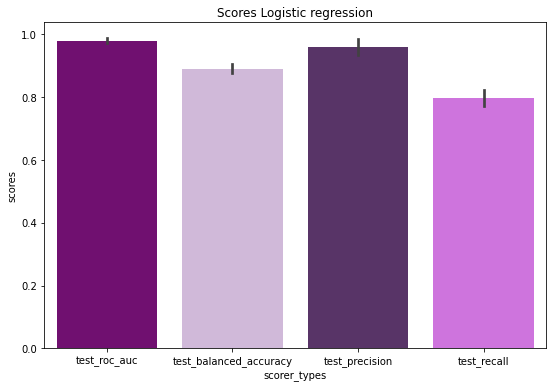

In [33]:
purples = ['#800080', '#D2B4DE', '#5b2c6f', '#DB63EE']
customPalette = sns.set_palette(sns.color_palette(purples))
plt.figure(figsize = (9, 6))
sns.barplot(data = tabella, x = 'scorer_types', y = 'scores', palette = purples)
plt.title("Scores Logistic regression")

In [13]:
print("ROC-AUC:", np.mean([0.97272727, 0.98275862, 0.98020434, 0.99425287, 0.96164021]))
print("PRECISION:", np.mean([0.95454545, 0.96      , 0.96      , 1.        , 0.91666667]))
print("RECALL:", np.mean([0.75      , 0.82758621, 0.82758621, 0.79310345, 0.78571429]))
print("BALANCED ACCURACY:", np.mean([0.86590909, 0.90453384, 0.90453384, 0.89655172, 0.87433862]))

ROC-AUC: 0.9783166619999999
PRECISION: 0.958242424
RECALL: 0.796798032
BALANCED ACCURACY: 0.889173422


In [14]:
print("ROC-AUC:", np.std([0.97272727, 0.98275862, 0.98020434, 0.99425287, 0.96164021]).round(3))
print("PRECISION:", np.std([0.95454545, 0.96      , 0.96      , 1.        , 0.91666667]).round(3))
print("RECALL:", np.std([0.75      , 0.82758621, 0.82758621, 0.79310345, 0.78571429]).round(3))
print("BALANCED ACCURACY:", np.std([0.86590909, 0.90453384, 0.90453384, 0.89655172, 0.87433862]).round(3))

ROC-AUC: 0.011
PRECISION: 0.026
RECALL: 0.029
BALANCED ACCURACY: 0.016


In [15]:
# testing how the model would perform with a random split of the data

In [16]:
import random
random.Random(4).shuffle(y)
clf = LogisticRegression(random_state=123)
scores = cross_validate(clf, data, y, cv=5, scoring = ['roc_auc', 'balanced_accuracy', 'precision', 'recall'])
scores

{'fit_time': array([0.00250196, 0.00219178, 0.00190711, 0.001508  , 0.00134587]),
 'score_time': array([0.00260615, 0.0022552 , 0.00171494, 0.001513  , 0.00199318]),
 'test_roc_auc': array([0.56103896, 0.56577267, 0.52681992, 0.49425287, 0.52116402]),
 'test_balanced_accuracy': array([0.50876623, 0.49074074, 0.5252235 , 0.53448276, 0.49074074]),
 'test_precision': array([0.5       , 0.        , 0.66666667, 1.        , 0.        ]),
 'test_recall': array([0.03571429, 0.        , 0.06896552, 0.06896552, 0.        ])}

In [17]:
all_scores=[]
label=[]
for i in scores.keys():
    all_scores.append(list(scores[i])[:])
    label.append(list([i]*5))

# df_scores = pd.DataFrame(all_scores, columns =['Scores'])
final = []
for lista in all_scores:
    for numbers in lista:
        final.append(numbers)
final_ = final[10::]

flat_labels2 = [item for sublist in label for item in sublist]
tabella2 = pd.DataFrame(final_, columns = ['scores'])
tabella2['scorer_types'] = flat_labels2[10::]

(0.0, 1.0)

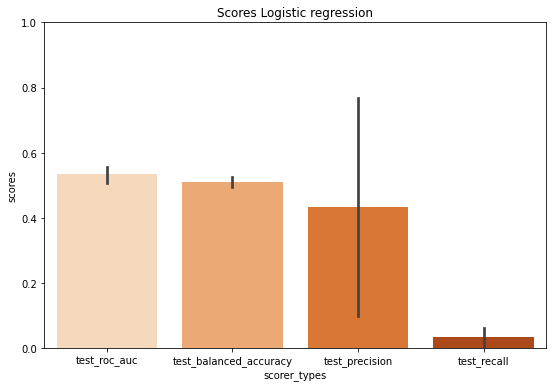

In [26]:
colors = ["#FF0B04", "#4374B3"]

# Set your custom color palette
customPalette = sns.set_palette(sns.color_palette(colors))
plt.figure(figsize = (9, 6))
sns.barplot(data = tabella2, x = 'scorer_types', y = 'scores', palette = 'Oranges')
plt.title("Scores Logistic regression")
plt.ylim(0,1)

In [19]:
### SILUETTE SCORES A vs B

In [20]:
from sklearn.metrics import silhouette_samples, silhouette_score
silhouette_avg = silhouette_score(data, indices.iloc[:,0].ravel())

In [21]:
silhouette_avg

-0.0019175151518301767

In [22]:
sample_silhouette_values = silhouette_samples(data, indices.iloc[:,0].ravel())

In [23]:
np.mean(sample_silhouette_values[indices.iloc[:,0].ravel()==0])

-0.0020632679433308493

In [24]:
np.mean(sample_silhouette_values[indices.iloc[:,0].ravel()==1])

-0.0016412983231820488